# **SIMULATION SUITE**

### **1. Problem Setup**

Let us discuss the mathematical setup of the problem in a fair amount of mathematical detail.

### **2. Simulation Data**

We now visualise the simulation data provided by Mouad. Firstly, we important all required modules and load the data,

In [1]:
# Dependencies,
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
from scipy.stats import qmc
from sklearn.model_selection import train_test_split

# Loading the simulation data,
with h5py.File("cylinder_Re100.h5", "r") as file:
    t = file["t"][:]
    u = file["u"][:]
    v = file["v"][:]
    p = file["p"][:]
    x = file["x"][:]
    y = file["y"][:]

"""USE THIS CODE TO LOAD MODEL PREDICTIONS."""
u_pred = np.load("u_pred_baseline.npy")
v_pred = np.load("v_pred_baseline.npy")
p_pred = np.load("p_pred_baseline.npy")

Inspecting the our time values `t`, we confirm that we have `201` time steps that range from `t=400` to `t=420`. Each step represents `0.1` units of time. Moreover, we have `82,872` number of nodes which take one a value of $u$, $v$ and $p$ at a given time $t$. Let us now visualise the velocity field for a given time $t$,

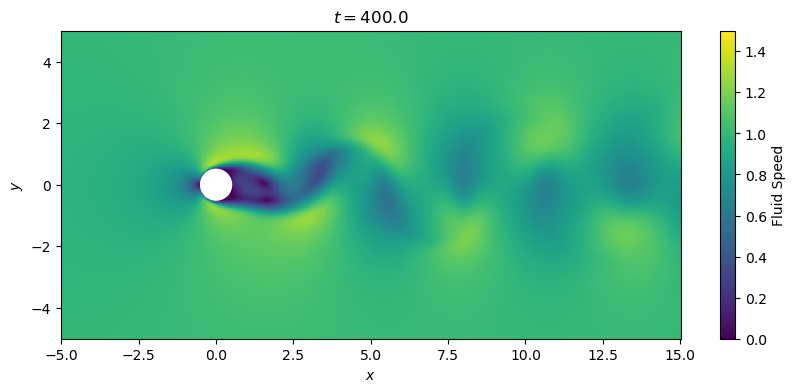

In [2]:
def compute_speed_grid(u, v, p, x, y, t, time_idx=0, padding=0.25, grid_res=(500, 500), region = (-5, 15, -5, 5)):
    """Computes the speed grid and returns it along with the mesh grid when supplied with the simulation
    data."""

    # Extracting temporal snapshot,
    u_snap, v_snap, p_snap, x_snap, y_snap, t_snap = u[time_idx], v[time_idx], p[time_idx], x[time_idx], y[time_idx], t[time_idx]

    # Selecting region of interest,
    x_min, x_max, y_min, y_max = region[0], region[1], region[2], region[3]

    # Applying boolean mask,
    bool_mask = (x_snap >= x_min-padding) & (x_snap <= x_max+padding) & (y_snap >= y_min-padding) & (y_snap <= y_max+padding) 
    u_snap, v_snap, p_snap, x_snap, y_snap = u_snap[bool_mask], v_snap[bool_mask], p_snap[bool_mask], x_snap[bool_mask], y_snap[bool_mask]

    # Computing the speed (scalar field),
    speed = np.sqrt(u_snap**2 + v_snap**2)

    # Creating mesh grid,
    nx, ny = grid_res # <-- grid resolution.
    xi = np.linspace(start=x_min, stop=x_max, num=nx)
    yi = np.linspace(start=y_min, stop=y_max, num=ny)
    X_grid, Y_grid = np.meshgrid(xi, yi)

    # Interpolation (creating speed and pressure grids),
    speed_grid = griddata(
        points=np.column_stack([x_snap, y_snap]),
        values=speed,
        xi=(X_grid, Y_grid),
        method='cubic'
    )

    return speed_grid, t_snap, X_grid, Y_grid

# Computing speed grid (initial time),
speed_grid, t_snap, X_grid, Y_grid = compute_speed_grid(u, v, p, x, y, t, time_idx=0)

# Creating patch for the cylinder,
cylinder = plt.Circle(xy=(0, 0), radius=0.5, color="white")

# Plotting,
fig, ax = plt.subplots(figsize=(10, 4))
pcm = ax.pcolormesh(X_grid, Y_grid, speed_grid, shading="auto", cmap="viridis", vmin=0, vmax=1.5)
ax.add_patch(cylinder)
fig.colorbar(pcm, ax=ax, label="Fluid Speed")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title(f"$t={t_snap}$")
plt.show()

Now we create an animation,

KeyboardInterrupt: 

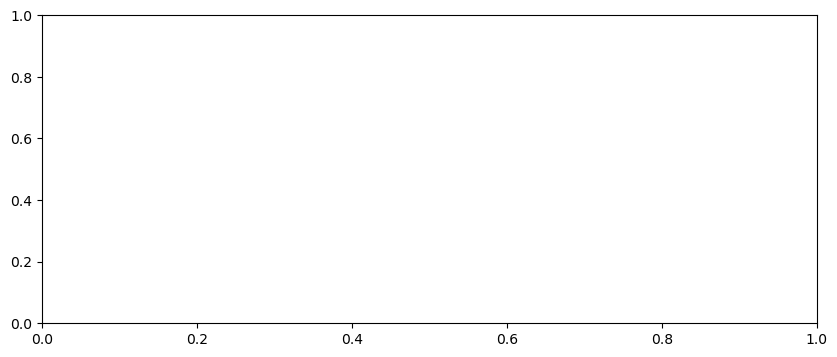

In [3]:
def update_frame(frame):
    global mesh, title
    speed_grid, t_snap, _, _ = compute_speed_grid(u, v, p, x, y, t, time_idx=frame)
    mesh.set_array(speed_grid.ravel())
    title.set_text(f"$t = {t_snap}$")
    return mesh, title

# Creating figure,
cylinder = plt.Circle(xy=(0, 0), radius=0.5, color="white")
fig, ax = plt.subplots(figsize=(10, 4))
speed_grid_init, t_0, X_grid, Y_grid = compute_speed_grid(u, v, p, x, y, t, time_idx=0)
mesh = ax.pcolormesh(X_grid, Y_grid, speed_grid_init, shading="auto", cmap="viridis", vmin=0, vmax=1.5)
fig.colorbar(mesh, label="Fluid Speed")
ax.add_patch(cylinder)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
title = ax.set_title(f"$t = {t_0}$")

# Constucting animation,
ani = FuncAnimation(fig=fig,
                    func=update_frame,
                    frames=100,
                    interval=100,
                    blit=True)

# Saving animation,
ani.save("fluid_flow_ground_truth.mp4", writer="ffmpeg", fps=10)

There are a few things to consider when creating the animation. There are `200` snapshots (including the snapshot of the initial state of the system) which begin from the intial time `t=400` to final time of `t=420`. Assuming that the units of time are seconds (they are actually have no units in the simulation), the time between each snapshot or frame is `100 ms` which corresponds to `10` FPS. To create the animation, we only consider `10` of the `20` seconds of the simulation. Considering that it takes approximately `2 s` to generate a single frame/snapshot on my computer, it will take around three to five minutes (with `blit=True`) to render this animation.

### **3. Creating Training Data**

Let us create a dataset by sampling $N$ number of points from the entire spatial-temporal domain $\Omega$ using Latin Hypercube Sampling (LHS). We consider a region of interest (ROI) near the cylinder defined by $-5 \leq x \leq 15$ and $-5 \leq y \leq 5$. We choose to sample `N_sample=500,000` points in the fluid field which approximately 3% of the total points in the spatial-temporal domain $\Omega$. We also flag these samples with `0` to indicate that they do not lie on the cylinder boundary (there is a small chance that a given point may lie on the cylinder boundary, but the probability is negligible).

In [13]:
# Number of sample points,
N_sample = 500000

# Defining ROI,
x_min, x_max = -5, 15
y_min, y_max = -5, 5
t_min, t_max = 400, 420

# Creating sampler object,
sampler = qmc.LatinHypercube(d=3)
samples = sampler.random(n=N_sample)

# Scaling sampling points,
samples = qmc.scale(samples, 
                    l_bounds=[x_min, y_min, t_min], 
                    u_bounds=[x_max, y_max, t_max]
)

# Creating flags,
flags = np.zeros(shape=N_sample)

To _"bake"_ in the presence of the cylinder and its boundary condition, we heavily sample its boundary and interior. According to the simulation's paper, the centre of the cylinder is at the origin $(0, 0)$ and its diameter is $D$. Despite not being explicitly mentioned in the paper, for convenience, the cylinder should have a unit diameter $D=1$ which means that its radius is $R=0.5$. For each time step $t$ we select `n_points=100` number of random samples along the cylinder boundary. The method `cylinder_boundary` uses the parameteric equation of a circle to sample the points and `np.random.uniform` for the random process. In addition to the `500,000` field points sampled, we have `100 x 201 = 20,100` boundary points sampled across all times. We use `1` flags to denote that these points have been sampled from the boundary.

In [18]:
def cylinder_boundary(n_points, loc=(0, 0), radius=0.5):
    """Uses the parameteric equation to randomly sample points on the boundary of a circle."""

    # Each theta defines a point,
    theta = np.random.uniform(low=0, high=2*np.pi, size=n_points)

    # Computing points,
    x = loc[0] + radius * np.cos(theta)
    y = loc[1] + radius * np.sin(theta)
    points = np.column_stack((x, y))

    return points

# Generating boundary samples,
N_points = 100 # <-- Number of boundary points per time step.
boundary_samples = []
for t_step in t:
    boundary_xy = cylinder_boundary(n_points=N_points, loc=(0, 0), radius=0.5)
    boundary_xyt = np.column_stack((boundary_xy, np.full(N_points, t_step)))
    boundary_samples.append(boundary_xyt)
boundary_samples = np.vstack(boundary_samples) # <-- Stacking boundary samples across all times.
boundary_flags = np.ones(shape=N_points*201)

# Adding combining field and boundary samples,
samples = np.concatenate((samples, boundary_samples), axis=0)
flags = np.concatenate((flags, boundary_flags), axis=0)

We must round each time coordinate of each sample to the nearest `0.1`,

In [23]:
# Rounding time coordinates,
samples.T[2] = samples.T[2].round(decimals=1).astype(float)

Now we reach a slightly tricky part, we need to assign the respective $u$, $v$ and $p$ to each sample at the location $(x, y, t)$ in the domain. However, $(x, y, t)$ does not respond exactly to our node locations. To handle this, we use k-dimensional tree to assign the each point (x, y) to its nearest node for some time $t$.

In [24]:
# Formatting data,
x_sampled, y_sampled, t_sampled = samples.T
t_idxs = np.searchsorted(t, t_sampled) # <-- Mapping each sampled time coordinate.
xy_nodes = np.row_stack((x[0], y[0])).T

# Building tree,
tree = cKDTree(xy_nodes)

# Vectorised spatial lookup,
query_points = np.column_stack((x_sampled, y_sampled))
_, sampled_node_idxs = tree.query(query_points)

# Vectorised field extraction,
u_sampled = u[t_idxs, sampled_node_idxs]
v_sampled = v[t_idxs, sampled_node_idxs]
p_sampled = p[t_idxs, sampled_node_idxs]

We can visualise the points we have sampled in the domain,

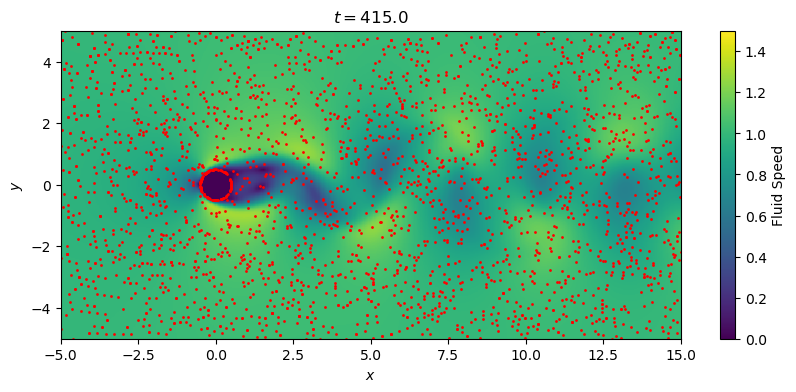

In [28]:
# Finding nodes which were sampled at a given time t,
time_idx = 150
selected_sample_idxs = np.where(t_idxs == time_idx)[0]
selected_node_idxs = sampled_node_idxs[selected_sample_idxs]
nodes_x = x[time_idx][selected_node_idxs]
nodes_y = y[time_idx][selected_node_idxs]

# Computing speed grid (initial time),
speed_grid, t_snap, X_grid, Y_grid = compute_speed_grid(u, v, p, x, y, t, time_idx=time_idx)

# Plotting,
plt.figure(figsize=(10, 4))
plt.pcolormesh(X_grid, Y_grid, speed_grid, shading="auto", cmap="viridis", vmin=0, vmax=1.5)
plt.colorbar(label="Fluid Speed")
plt.scatter(x=nodes_x, y=nodes_y, s=1, color="red")
plt.xlim((x_min, x_max))
plt.ylim((y_min, y_max))
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(f"$t={t_snap}$")
plt.show()

The final stage is to now store our sampled points as a dataset,

In [49]:
# Our input is the temporal-spatial domain with the flags (x, y, t, f),
X = np.column_stack((x_sampled, y_sampled, t_sampled, flags))

# The targets are the velocity U = (u, v) and pressure p fields,
Y = np.column_stack((u_sampled, v_sampled, p_sampled))

# Creating data split,
X_train, X_test_val, y_train, y_test_val = train_test_split(X, Y, test_size=0.1, random_state=0, shuffle=True)
X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.2, random_state=0, shuffle=True)

# Saving dataset,
np.savez("data_train.npz",X_train=X_train,y_train=y_train)
np.savez("data_test.npz",X_test=X_test,y_test=y_test)
np.savez("data_validation.npz",X_val=X_val,y_val=y_val)

# References


Numerical simulation data of a two-dimensional flow around a fixed circular cylinder. Boudina (2021). URL: https://zenodo.org/records/5039610
